# Classificação de Renda

Projeto de **Machine Learning** desenvolvido para prever se a renda anual de um indivíduo é **superior a US$ 50.000**, utilizando dados do censo e o algoritmo **Gaussian Naive Bayes**.

## Objetivo

Realizar uma classificação:

* `<=50K` — renda anual igual ou inferior a US$ 50.000
* `>50K` — renda anual superior a US$ 50.000

## Dataset

Foi utilizado o **Adult / Census Income Dataset**, disponibilizado pelo **UCI Machine Learning Repository**.

O dataset foi extraído por **Barry Becker** a partir da base do **Census Database de 1994**. A tarefa original consiste em prever se a renda anual de um indivíduo ultrapassa US$ 50.000.

**Fonte:** [UCI Machine Learning Repository — Adult Dataset](https://archive.ics.uci.edu/dataset/2/adult)

## Variáveis

| Variável         | Descrição                                     |
| ---------------- | --------------------------------------------- |
| `age`            | Idade do indivíduo                            |
| `workclass`      | Classe/categoria de trabalho                  |
| `final-weight`   | Peso final utilizado na amostragem censitária |
| `education`      | Nível de escolaridade                         |
| `education-num`  | Representação numérica da escolaridade        |
| `marital-status` | Estado civil                                  |
| `occupation`     | Ocupação profissional                         |
| `relationship`   | Relação do indivíduo dentro da família        |
| `race`           | Raça                                          |
| `sex`            | Sexo                                          |
| `capital-gain`   | Ganho de capital                              |
| `capital-loos`   | Perda de capital                              |
| `hour-per-week`  | Horas trabalhadas por semana                  |
| `native-country` | País de origem                                |
| `income`         | Variável-alvo: `<=50K` ou `>50K`              |

## Análise Exploratória

Foram realizadas análises para compreender a estrutura do dataset, incluindo:

* visualização das primeiras observações;
* estatísticas descritivas;
* verificação de valores ausentes;
* análise da quantidade de registros por classe de `income`;
* distribuição das variáveis `age`, `education-num` e `hour-per-week`.

## Pré-processamento

As variáveis categóricas foram transformadas utilizando **One-Hot Encoding**, convertendo suas categorias em variáveis binárias (`0` e `1`).

As variáveis numéricas foram mantidas em sua representação quantitativa.

Após a transformação, o conjunto de dados passou a ter **108 características**.

Os dados foram posteriormente divididos em:

* **70% para treinamento**
* **30% para teste**

## Modelo

Foi utilizado o **Gaussian Naive Bayes (`GaussianNB`)**.

O algoritmo utiliza o **Teorema de Bayes** para estimar a probabilidade de cada classe e assume independência entre as características.

A escolha permite trabalhar com as variáveis numéricas presentes no dataset e com as características binárias geradas pelo One-Hot Encoding.

## Avaliação

O modelo foi avaliado utilizando:

* **Acurácia**
* **Matriz de Confusão**

### Resultado

**Acurácia: 79,74%**

A matriz de confusão permite visualizar a quantidade de classificações corretas e incorretas para cada classe de renda.

## Conclusão

O projeto apresenta um fluxo completo de classificação utilizando **Machine Learning**, passando pela análise exploratória, transformação das variáveis categóricas, divisão dos dados, treinamento do **Gaussian Naive Bayes** e avaliação de seu desempenho.

O modelo alcançou **79,74% de acurácia** no conjunto de teste.


In [2]:
# Importando as bibliotecas
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [3]:
# Lendo os dados
df = pd.read_csv('census.csv')

In [4]:
# Visualizando as primeiras linhas
df.head()

,age,workclass,final-weight,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loos,hour-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Descrição dos dados
df.describe()

,age,final-weight,education-num,capital-gain,capital-loos,hour-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Conferindo valores ausentes
df.isnull().sum()

age               0
workclass         0
final-weight      0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loos      0
hour-per-week     0
native-country    0
income            0
dtype: int64

In [7]:
# Número de linhas e colunas
df.shape

(32561, 15)

In [8]:
# Quantidade de cada classe na variável alvo income 
np.unique(df['income'], return_counts = True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

(<Axes: xlabel='income', ylabel='count'>,)

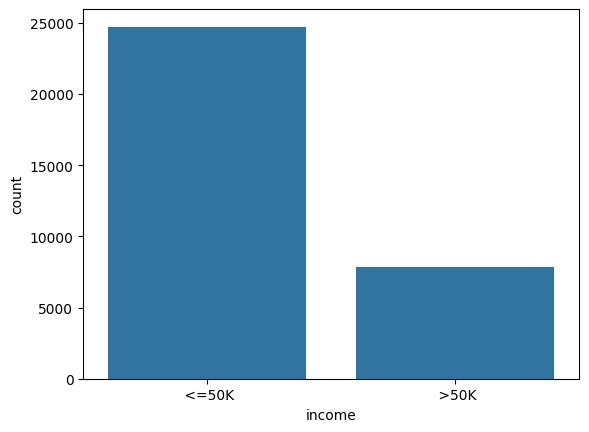

In [9]:
# Visualizando a distribuição da variável alvo income 
sns.countplot(x = df['income']),

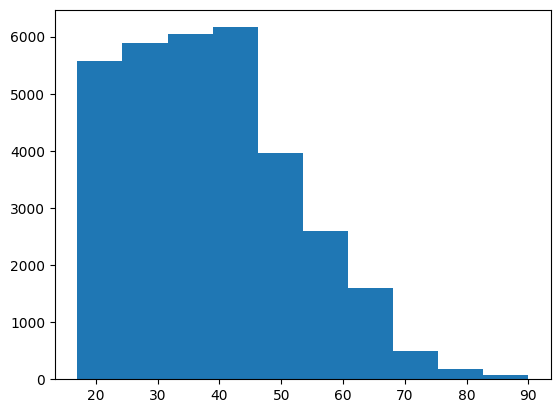

In [10]:
# Visualizando a distribuição da variável age
plt.hist(x = df['age']);

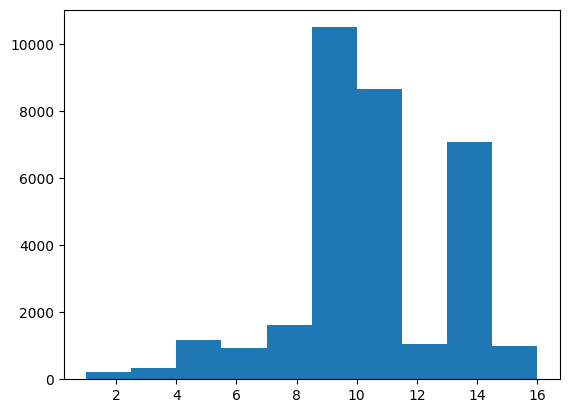

In [11]:
# Visualizando a distribuição da variável education-num
plt.hist(x = df['education-num']);

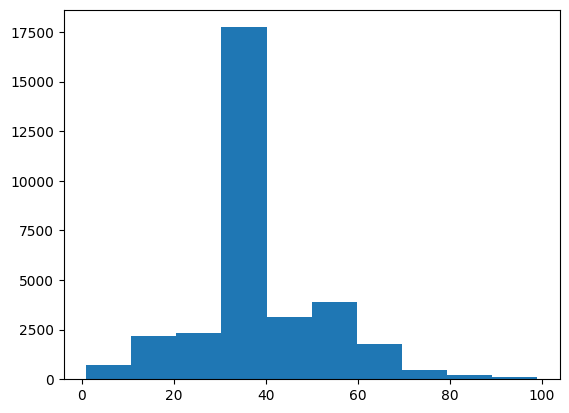

In [12]:
# Visualizando a distribuição da variável hour-per-week
plt.hist(x = df['hour-per-week']);

In [13]:
# Separando as variáveis preditoras
x = df.iloc[:, 0:14].values
x

array([[39, ' State-gov', 77516, ..., 0, 40, ' United-States'],
       [50, ' Self-emp-not-inc', 83311, ..., 0, 13, ' United-States'],
       [38, ' Private', 215646, ..., 0, 40, ' United-States'],
       ...,
       [58, ' Private', 151910, ..., 0, 40, ' United-States'],
       [22, ' Private', 201490, ..., 0, 20, ' United-States'],
       [52, ' Self-emp-inc', 287927, ..., 0, 40, ' United-States']],
      shape=(32561, 14), dtype=object)

In [14]:
# Separando a variável alvo
y = df.iloc[:, 14].values
y

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' >50K'],
      shape=(32561,), dtype=object)

In [15]:
# Transformando os dados categóricos com OneHotEncoder
onehotencoder = ColumnTransformer(transformers=[('OneHot', OneHotEncoder(), [1, 3, 5, 6, 7, 8, 9, 13])], remainder='passthrough')
x = onehotencoder.fit_transform(x)
x[1]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 12 stored elements and shape (1, 108)>

In [16]:
# Verificando a dimensão
x.shape

(32561, 108)

In [17]:
# Divisão das bases de treinamento e teste
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.30, random_state = 0)

In [18]:
# Verificando as dimensões
x_treino.shape, y_treino.shape

((22792, 108), (22792,))

In [19]:
# Verificando as dimensões
x_teste.shape, y_teste.shape

((9769, 108), (9769,))

In [20]:
# Criando o modelo 
modelo = GaussianNB()
modelo.fit(x_treino.toarray(), y_treino)

GaussianNB()

In [21]:
# Realizando previsões com os dados de teste
previsoes = modelo.predict(x_teste.toarray())
previsoes

array([' <=50K', ' <=50K', ' <=50K', ..., ' >50K', ' <=50K', ' <=50K'],
      shape=(9769,), dtype='<U6')

In [22]:
# Conferindo a acurácia do modelo
accuracy_score(y_teste, previsoes)

0.7974204115057836

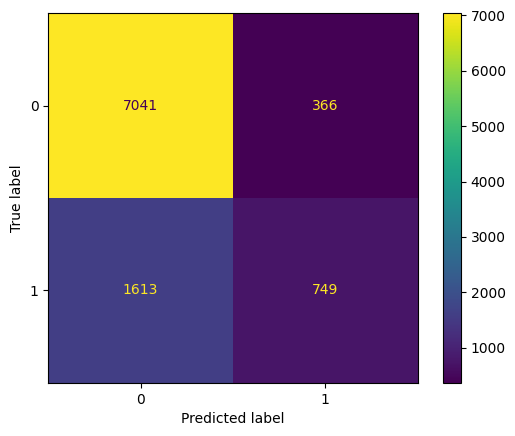

In [23]:
# Visualizando a matriz de confusão 
matriz_confusao = confusion_matrix(y_teste, previsoes)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz_confusao)
disp.plot();